In [1]:
#---IMPORTS---
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim


In [2]:
#---CONFIGS---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 10
BATCH_SIZE = 64
IMG_SIZE = 64
NOISE_DIM = 100
IMG_CHANNEL = 1
FEATURE_C = 16
FEATURE_G = 16
LR = 1e-4
CRIT_ITERS = 5
LAMBDA_GP = 10

In [3]:
#---DATASET---
transform = transforms.Compose([
    transforms.Resize(size=IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5 for _ in range(IMG_CHANNEL)],[0.5 for _ in range(IMG_CHANNEL)])
    ])

dataset = datasets.MNIST(root= "data",
                         train= True,
                         transform= transform,
                         download= True)

loader = DataLoader(dataset= dataset,
                    batch_size= BATCH_SIZE,
                    shuffle= True)

In [4]:
print(f"Dataset Size: {len(dataset)}")
print(f"Total Batches : {len(loader)}")

batch_shape, _  = next(iter(loader))
print(f"Shape of Batch: {batch_shape.shape}")

Dataset Size: 60000
Total Batches : 938
Shape of Batch: torch.Size([64, 1, 64, 64])


In [5]:
#---MODELS---
class Critic(nn.Module):
    def __init__(self, IMG_CHANNEL, FEATURE_C):
        super().__init__()

        self.crit = nn.Sequential(
            #1->16, (64,64)
            nn.Conv2d(in_channels= IMG_CHANNEL, out_channels= FEATURE_C, kernel_size= 4, stride= 2, padding= 1), #(32, 32)
            nn.LeakyReLU(0.2),

            #16->32, (32,32)
            self._block(in_channels= FEATURE_C, out_channels= FEATURE_C*2, kernel_size= 4, stride= 2, padding= 1), #(16, 16)
            
            #32->64, (16,16)
            self._block(in_channels= FEATURE_C*2, out_channels= FEATURE_C*4, kernel_size= 4, stride= 2, padding= 1), #(8, 8)

            #64->128, (8,8)
            self._block(in_channels= FEATURE_C*4, out_channels= FEATURE_C*8, kernel_size= 4, stride= 2, padding= 1), #(4, 4)

            #128->256, (4,4)
            nn.Conv2d(in_channels=FEATURE_C*8, out_channels= IMG_CHANNEL, kernel_size= 4, stride= 2, padding= 0), #(1,1)
            
            #256->1, (1,1)
            )
        
    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels= in_channels,
                      out_channels= out_channels,
                      kernel_size= kernel_size,
                      stride= stride,
                      padding= padding,
                      bias= True),

            nn.InstanceNorm2d(out_channels, affine=True), 
            nn.LeakyReLU(0.2)
            )
    
    def forward(self, x):
        return self.crit(x)
    



class Generator(nn.Module):
    def __init__(self, NOISE_DIM, FEATURE_G, IMG_CHANNEL):
        super().__init__()

        self.gen = nn.Sequential(
            #100->256, (1,1)
            self._block(in_channels= NOISE_DIM, out_chanels= FEATURE_G*16, kernel_size= 4, stride= 1, padding= 0), #(4,4)

            #256->128, (4,4)
            self._block(in_channels= FEATURE_G*16, out_chanels= FEATURE_G*8, kernel_size= 4, stride= 2, padding= 1), #(8,8)

            #128->64, (8,8)
            self._block(in_channels= FEATURE_G*8, out_chanels= FEATURE_G*4, kernel_size= 4, stride= 2, padding= 1), #(16,16)

            #64->32, (16,16)
            self._block(in_channels= FEATURE_G*4, out_chanels= FEATURE_G*2, kernel_size= 4, stride= 2, padding= 1), #(32,32)

            #32->16, (32, 32)
            nn.ConvTranspose2d(in_channels= FEATURE_G*2, out_channels= IMG_CHANNEL, kernel_size= 4, stride= 2, padding= 1), #(64, 64)

            nn.Tanh()
        )

    def _block(self, in_channels, out_chanels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels= in_channels,
                               out_channels= out_chanels,
                               kernel_size= kernel_size,
                               stride= stride,
                               padding= padding,
                               bias= False),

            nn.BatchNorm2d(out_chanels),
            nn.ReLU()
            )
    
    def forward(self, x):
        return self.gen(x)
    



def init_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)



def test():

    batch_size, img_channel, height, width = 8, 1, 64, 64
    noise_dim = 100

    crit = Critic(IMG_CHANNEL= img_channel, FEATURE_C= FEATURE_C)
    gen = Generator(NOISE_DIM= noise_dim, FEATURE_G= FEATURE_G, IMG_CHANNEL= img_channel)

    real = torch.randn((batch_size, img_channel, height, width))
    print(crit(real).shape)
    assert crit(real).shape == (batch_size, img_channel, 1, 1), "Critic test failed"
    

    noise = torch.randn(batch_size, noise_dim, 1, 1)
    print(gen(noise).shape)
    assert gen(noise).shape == (batch_size, img_channel, height, width), "Generator test failed"


test()

torch.Size([8, 1, 1, 1])
torch.Size([8, 1, 64, 64])


In [6]:
#---TRANING_SETUP---
crit = Critic(IMG_CHANNEL= IMG_CHANNEL, FEATURE_C= FEATURE_C).to(DEVICE)
init_weights(crit)

gen = Generator(NOISE_DIM= NOISE_DIM, FEATURE_G= FEATURE_G, IMG_CHANNEL= IMG_CHANNEL).to(DEVICE)
init_weights(gen)

crit_optim = optim.Adam(crit.parameters(), lr= LR, betas=(0.0, 0.9))
gen_optim = optim.Adam(gen.parameters(), lr= LR, betas=(0.0, 0.9))

fixed_noise = torch.randn(BATCH_SIZE, NOISE_DIM, 1, 1).to(DEVICE)

writer_real = SummaryWriter(f"logs/GAN_MNIST/real")
writer_fake = SummaryWriter(f"logs/GAN_MNIST/fake")
step = 0

In [7]:
#---GP---
def gradient_penalty(critic, real, fake, device= "cpu"):

    BATCH_SIZE, C, H, W = real.shape

    alpha = torch.rand((BATCH_SIZE, 1, 1, 1)).repeat(1, C, H, W).to(device)
    interpolated_images = real * alpha + fake * (1 - alpha)

    # Calculate critic scores
    mixed_scores = critic(interpolated_images)

    # Take the gradient of the scores with respect to the images
    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,)[0]
    
    gradient = gradient.view(gradient.shape[0], -1)
    gradient_norm = gradient.norm(2, dim=1)
    gradient_penalty = torch.mean((gradient_norm - 1) ** 2)
    return gradient_penalty

In [8]:
#---TRAINING_LOOP---
for epoch in range(EPOCHS):
    for batch, (real, _) in enumerate(loader):

        real = real.to(DEVICE)

        for i in range(CRIT_ITERS):

            noise = torch.randn(real.shape[0], NOISE_DIM, 1, 1).to(DEVICE)
            fake = gen(noise)

            crit_real = crit(real).reshape(-1)
            crit_fake = crit(fake).reshape(-1)

            gp = gradient_penalty(crit, real, fake, device=DEVICE)

            crit_loss = (
                -(torch.mean(crit_real) - torch.mean(crit_fake)) + LAMBDA_GP * gp
            )
            crit_optim.zero_grad()
            crit_loss.backward(retain_graph=True)
            crit_optim.step()


        output = crit(fake).reshape(-1)
        gen_loss = -torch.mean(output)
        gen_optim.zero_grad()
        gen_loss.backward()
        gen_optim.step()

        if batch % 100 == 0 and batch > 0:
            print(
                f"Epoch [{epoch}/{EPOCHS}] Batch {batch}/{len(loader)} \
                  Loss C: {crit_loss:.4f}, loss G: {gen_loss:.4f}"
            )

            with torch.no_grad():
                fake = gen(fixed_noise)
                
                img_grid_real = torchvision.utils.make_grid(real[:32], normalize=True)
                img_grid_fake = torchvision.utils.make_grid(fake[:32], normalize=True)

                writer_real.add_image("Real", img_grid_real, global_step=step)
                writer_fake.add_image("Fake", img_grid_fake, global_step=step)

            step += 1

Epoch [0/10] Batch 100/938                   Loss C: -111.3115, loss G: 63.2225
Epoch [0/10] Batch 200/938                   Loss C: -130.6414, loss G: 93.6003
Epoch [0/10] Batch 300/938                   Loss C: -126.2686, loss G: 110.1697
Epoch [0/10] Batch 400/938                   Loss C: -117.3624, loss G: 111.2692
Epoch [0/10] Batch 500/938                   Loss C: -107.5091, loss G: 107.0379
Epoch [0/10] Batch 600/938                   Loss C: -97.7445, loss G: 101.8839
Epoch [0/10] Batch 700/938                   Loss C: -86.2531, loss G: 93.8165
Epoch [0/10] Batch 800/938                   Loss C: -77.3577, loss G: 95.7367
Epoch [0/10] Batch 900/938                   Loss C: -64.7591, loss G: 91.2229
Epoch [1/10] Batch 100/938                   Loss C: -54.2307, loss G: 87.3327
Epoch [1/10] Batch 200/938                   Loss C: -45.0280, loss G: 84.1557
Epoch [1/10] Batch 300/938                   Loss C: -37.2475, loss G: 84.3374
Epoch [1/10] Batch 400/938                 

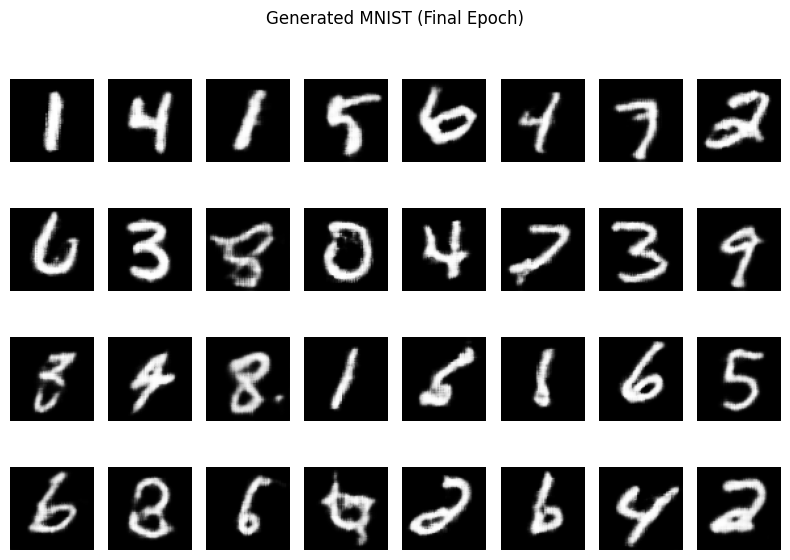

In [9]:
#---VISUALIZATION---
with torch.no_grad():
    sample = gen(fixed_noise).reshape(-1, 1, 64, 64).cpu()
    sample = sample * 0.5 + 0.5

    fig, axes = plt.subplots(4,8, figsize=(8, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(sample[i].permute(1, 2, 0).clamp(0, 1), cmap= 'gray')
        ax.axis("off")
    plt.suptitle("Generated MNIST (Final Epoch)")
    plt.tight_layout()
    plt.show()